# ***1 Standardization (Z-score Scaling)***

- **Definition:**
> 👉 Standardization is a feature scaling technique that transforms features so that they have a **mean = 0** and a **standard deviation = 1**.

### **Formula:**

$$
z=\frac{x-\mu}{\sigma}
$$

Where:

* **z** = Standardized (scaled) value
* **x** = Original value
* **μ** = Mean of the feature
* **σ** = Standard deviation of the feature

### **Effect:**

* The data becomes centered around zero.
* Outliers still have some influence.
* It is useful for algorithms that rely on distance or assume normally distributed data, such as **SVM, Logistic Regression, and PCA**.

### **Example:**

Salary column = **[30,000, 45,000, 28,000]**

* Mean ≈ 34,333
* Standard Deviation ≈ 9,0xx

If the value is **30,000**:

$$
z=\frac{30000-34333}{9000}\approx -0.48
$$

---

### **Range of Standardization**

**Standardization (Z-score Scaling)** does **not have a fixed range.**

### **Reason:**

The formula is:

$$
z=\frac{x-\mu}{\sigma}
$$

* After subtracting the mean (**μ**), the data becomes **centered around zero**.
* Dividing by the standard deviation (**σ**) adjusts the spread of the data.

### **Typical Range in Practice**

If the data follows a **normal distribution**:

* Approximately **68%** of the values lie within **[-1, +1]**.
* Approximately **95%** of the values lie within **[-2, +2]**.
* Approximately **99.7%** of the values lie within **[-3, +3]**.

This is known as the **Empirical Rule (68–95–99.7 Rule)**.

However, if the data is **skewed** or contains **many outliers**, standardized values can fall outside this range (for example, **-5** or **+7**).

---

### **Summary**

* **Normalization** has a **fixed range** (usually **0 to 1**).
* **Standardization** has **no fixed range**, but in practice, most values typically fall within **[-3, +3]**.


In [88]:
import pandas as pd
import numpy as np

In [89]:
df = pd.read_csv('Social_Network_Ads.csv')

In [90]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [91]:
df.shape

(400, 5)

In [92]:
df.drop(columns=['User ID','Gender'],inplace=True)

In [93]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [35]:
df.shape

(400, 3)

In [36]:
X =  df.drop('Purchased', axis=1)
y = df['Purchased']

## ***Train test split***

In [37]:
import sklearn
from sklearn.model_selection import train_test_split

In [87]:
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(320, 2) (80, 2)
(320,) (80,)


## ***StandardScaler***

In [69]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
ss.fit(X_train)

# transform train and test sets
X_train_scaled = ss.transform(X_train)
X_test_scaled = ss.transform(X_test)

In [70]:
ss.mean_

array([3.7871875e+01, 7.0281250e+04])

In [71]:
X_train

,Age,EstimatedSalary
3,27,57000
18,46,28000
202,39,134000
250,44,39000
274,57,26000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [72]:
X_test_scaled

array([[ 0.79753468, -1.40447546],
       [ 2.07309956,  0.51542886],
       [-0.96863208, -0.76450736],
       [ 0.99377543,  0.74814454],
       [-0.87051171, -1.22993871],
       [-0.77239133, -0.24089709],
       [ 0.89565505,  1.06812859],
       [-0.87051171,  0.36998156],
       [ 0.20881242,  0.13726589],
       [ 0.40505317, -0.15362871],
       [-0.28178945, -0.15362871],
       [ 1.4843773 , -1.05540195],
       [-1.45923396, -0.64814952],
       [-1.75359508, -1.37538601],
       [-0.77239133,  0.4863394 ],
       [-0.28178945,  1.09721805],
       [ 1.38625693, -0.93904411],
       [ 0.79753468,  0.10817643],
       [ 0.11069205, -0.82268628],
       [ 1.77873843, -0.29907601],
       [-1.55735433, -1.25902817],
       [-0.87051171,  0.28271318],
       [ 0.89565505, -1.37538601],
       [ 2.07309956,  0.16635535],
       [-1.85171546, -1.49174384],
       [ 1.28813655, -1.37538601],
       [ 0.40505317,  0.28271318],
       [-0.0855487 , -0.50270222],
       [ 1.68061805,

In [73]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [74]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,37.9,70281.2
std,10.2,34430.6
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [75]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


## ***Effect of the scaling***

In [76]:
import matplotlib.pyplot as plt

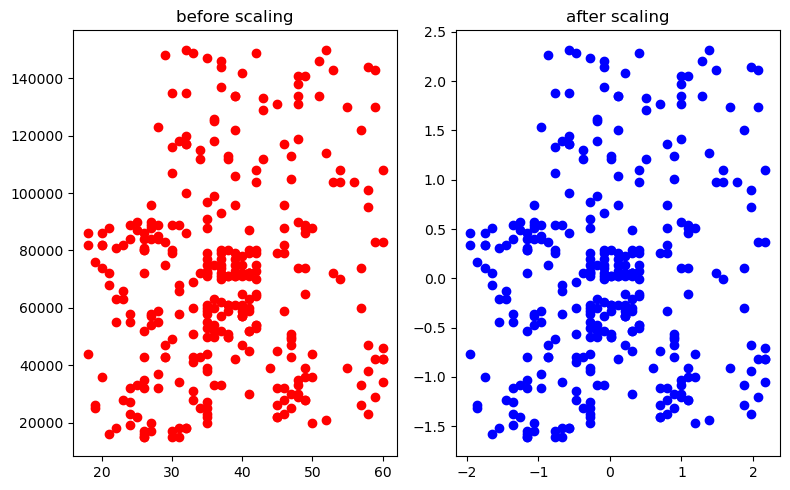

In [77]:
plt.figure(figsize=(8, 5))
plt.subplot(1,2,1)
plt.scatter(X_train['Age'],X_train['EstimatedSalary'],color = 'red')
plt.title('before scaling')
plt.subplot(1,2,2)
plt.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'], color='blue')
plt.title('after scaling')
plt.tight_layout()
plt.show()

In [78]:
import seaborn as sns

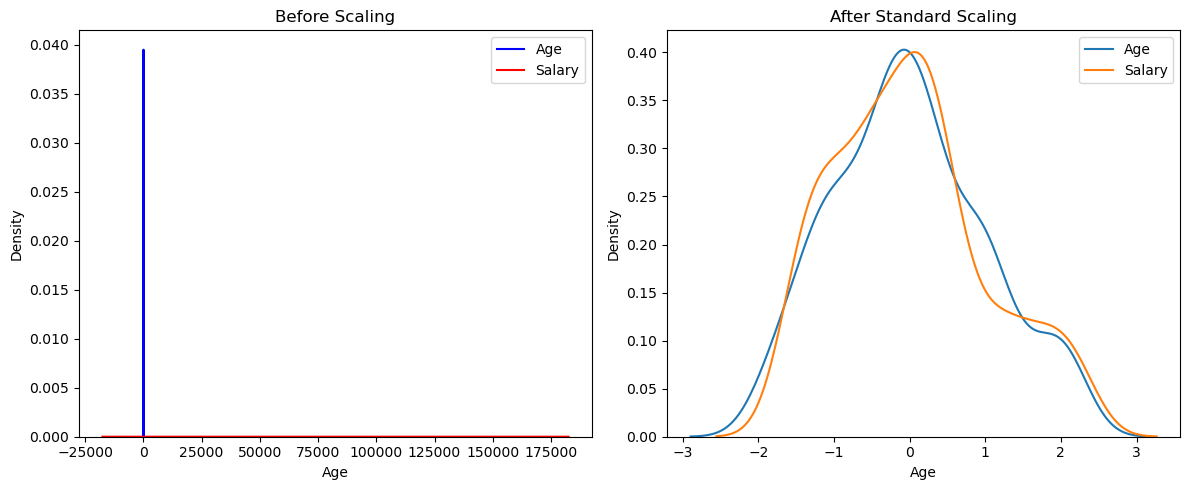

In [79]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1, label='Age', color='blue')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='Salary', color='red')
ax1.legend()
# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2,label='Age')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2,label='Salary')
ax2.legend()
plt.tight_layout()
plt.show()

### ***“After scaling, both features are transformed to a similar range (around -3 to +3) with mean 0 and standard deviation 1.”***

## ***Comparision of distribution***

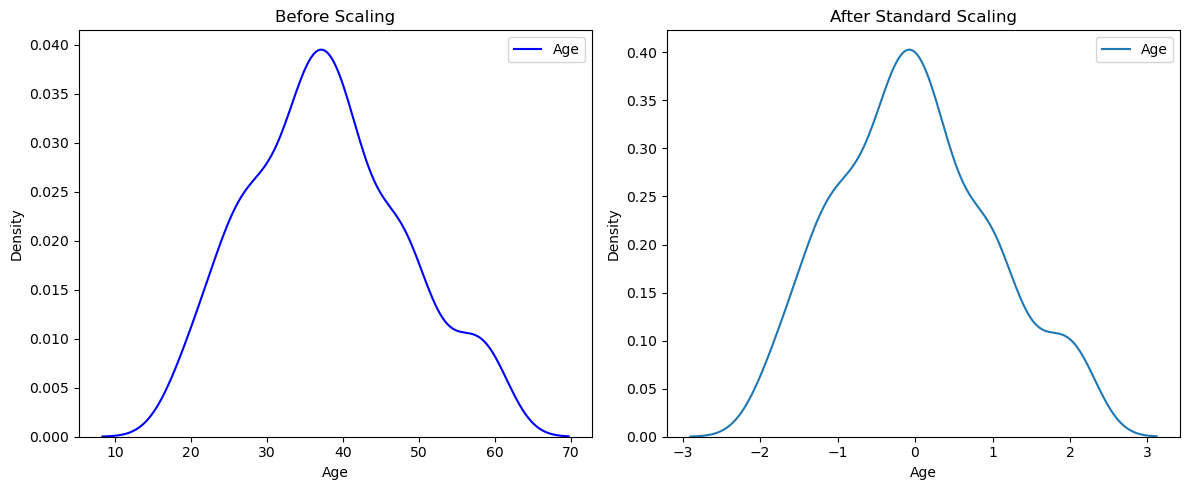

In [80]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1, label='Age', color='blue')

ax1.legend()
# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2,label='Age')

ax2.legend()
plt.tight_layout()
plt.show()

# ***Why scaling is important?****

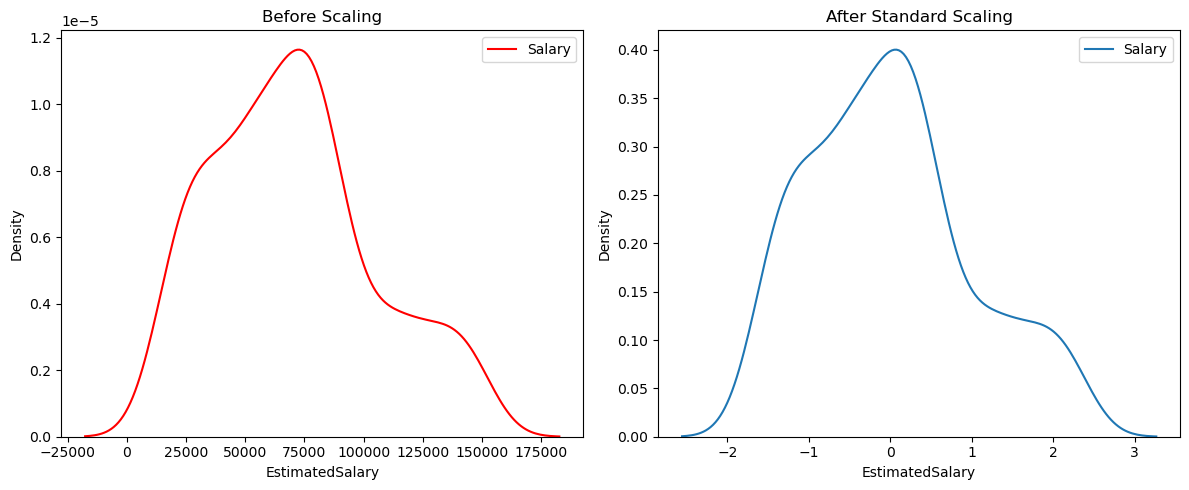

In [81]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='Salary', color='red')
ax1.legend()
# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2,label='Salary')
ax2.legend()
plt.tight_layout()
plt.show()

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [84]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [85]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [86]:
from sklearn.metrics import accuracy_score
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8875
Scaled 0.8625


In [94]:
from sklearn.tree import DecisionTreeClassifier

In [95]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [96]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [97]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [98]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8375
Scaled 0.8375


# ***Effect of outliers***

In [101]:
import pandas as pd

new_data = pd.DataFrame({
    'Age':[5,90,95],
    'EstimatedSalary':[1000,250000,350000],
    'Purchased':[0,1,1]
})

df = pd.concat([df, new_data], ignore_index=True)

In [102]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


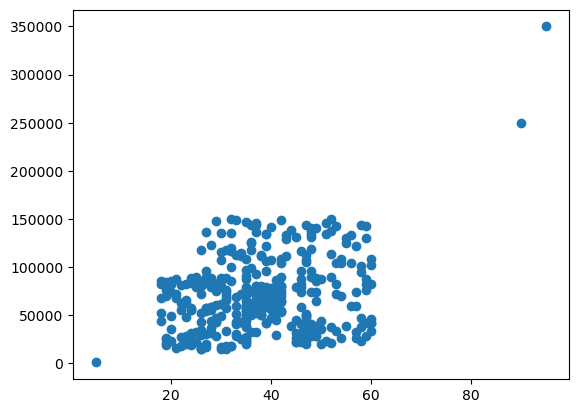

In [103]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [104]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

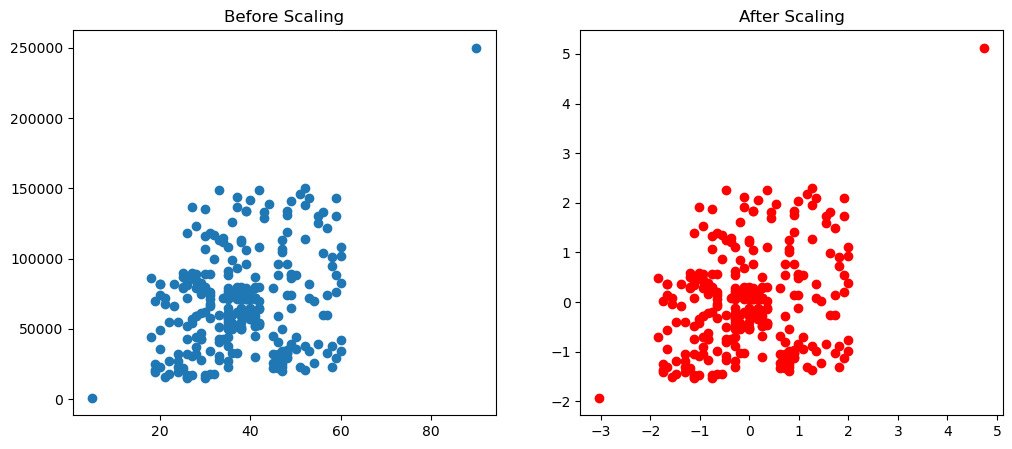

In [107]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()